In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import  mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import torch.nn as nn

In [2]:
#читаем данные
df = pd.read_csv('housing.csv')
df

,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,sub_area,area_m,...,metro_min_walk,metro_km_walk,mkad_km,kremlin_km,green_part_1000,prom_part_1000,office_count_1000,trc_count_1000,leisure_count_1000,price_doc
0,38,18.0,1.0,14.0,panel,1971.0,1.0,9.0,Dmitrovskoe,7.126815e+06,...,27.084184,2.257015,2.442781,14.856442,17.16,10.33,2,4,0,5150000
1,41,17.0,14.0,16.0,panel,1978.0,1.0,10.0,Savelovskoe,2.641243e+06,...,13.719174,1.143264,11.528984,5.323699,0.90,39.48,17,3,0,5980000
2,41,20.0,11.0,14.0,panel,1989.0,1.0,8.0,Krjukovo,1.084231e+07,...,276.453594,23.037800,20.828299,38.988909,7.54,6.64,0,2,0,4600000
3,38,19.0,6.0,17.0,panel,1986.0,1.0,8.0,Brateevo,7.587523e+06,...,14.085660,1.173805,2.885041,14.921056,24.97,0.00,0,5,0,5650000
4,58,37.0,3.0,9.0,panel,1968.0,3.0,6.0,Novogireevo,4.395333e+06,...,5.455795,0.454650,1.920884,11.812614,3.46,5.41,0,4,4,9300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8889,51,32.0,3.0,12.0,breezeblock,1974.0,2.0,9.0,Pechatniki,1.844581e+07,...,17.320003,1.443334,6.756490,9.929204,13.61,4.32,1,0,0,8300000
8890,76,45.0,6.0,16.0,panel,2001.0,3.0,10.0,Mar'ino,1.175477e+07,...,23.956840,1.996403,3.393475,13.991498,19.97,0.00,0,5,0,12800000
8891,78,43.0,15.0,17.0,panel,2002.0,3.0,13.0,Severnoe Butovo,8.889467e+06,...,3.497793,0.291483,1.056678,19.965501,20.83,0.00,0,7,0,15500000
8892,54,28.0,7.0,16.0,breezeblock,1975.0,2.0,12.0,Ivanovskoe,1.020722e+07,...,30.095498,2.507958,0.795735,13.120257,26.06,0.16,0,2,0,8350000


In [3]:
# посмотрим на описательную статистику каждой переменной
df.describe()

,full_sq,life_sq,floor,max_floor,build_year,num_room,kitch_sq,area_m,green_zone_part,indust_part,...,metro_min_walk,metro_km_walk,mkad_km,kremlin_km,green_part_1000,prom_part_1000,office_count_1000,trc_count_1000,leisure_count_1000,price_doc
count,8894.000000,8894.000000,8894.000000,8894.000000,8859.000000,8894.000000,8894.000000,8.894000e+03,8894.000000,8894.000000,...,8883.000000,8883.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8894.000000,8.894000e+03
mean,51.724196,30.417248,6.733303,12.186755,1974.139745,1.952665,7.716101,1.108296e+07,0.189023,0.127519,...,31.475028,2.622919,5.531550,13.630503,14.796778,8.982299,2.933101,2.072296,0.360243,7.807093e+06
std,20.039067,13.506626,4.800781,5.639183,115.094557,0.862990,2.818154,1.051812e+07,0.161092,0.122523,...,54.975459,4.581288,4.445240,7.044961,12.579365,12.022843,7.307584,2.235402,1.239451,5.024875e+06
min,12.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.081628e+06,0.001879,0.000000,...,0.000000,0.000000,0.093326,0.072897,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+05
25%,38.000000,19.000000,3.000000,9.000000,1966.000000,1.000000,6.000000,5.686537e+06,0.063755,0.033494,...,9.904819,0.825402,2.315584,9.296152,5.440000,0.000000,0.000000,0.000000,0.000000,5.450861e+06
50%,45.000000,29.000000,5.000000,12.000000,1976.000000,2.000000,8.000000,8.464344e+06,0.133373,0.090799,...,16.265692,1.355474,4.402202,12.890028,10.630000,4.010000,1.000000,2.000000,0.000000,6.950000e+06
75%,60.000000,38.000000,9.000000,16.000000,1995.000000,3.000000,9.000000,1.249544e+07,0.300284,0.194489,...,25.876968,2.156414,7.598405,15.808401,21.547500,13.400000,3.000000,3.000000,0.000000,9.200000e+06
max,275.000000,232.000000,77.000000,57.000000,4965.000000,17.000000,57.000000,2.060718e+08,0.852923,0.521867,...,711.215806,59.267984,53.277832,70.738769,100.000000,72.200000,84.000000,20.000000,30.000000,8.077744e+07


In [4]:
# найдм типы переменных по столбцам
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8894 entries, 0 to 8893
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   full_sq             8894 non-null   int64  
 1   life_sq             8894 non-null   float64
 2   floor               8894 non-null   float64
 3   max_floor           8894 non-null   float64
 4   material            8894 non-null   str    
 5   build_year          8859 non-null   float64
 6   num_room            8894 non-null   float64
 7   kitch_sq            8894 non-null   float64
 8   sub_area            8894 non-null   str    
 9   area_m              8894 non-null   float64
 10  green_zone_part     8894 non-null   float64
 11  indust_part         8894 non-null   float64
 12  preschool           8894 non-null   int64  
 13  school              8894 non-null   int64  
 14  healthcare          8894 non-null   int64  
 15  shopping            8894 non-null   int64  
 16  office           

In [5]:
# посмотрим невывденные столбцы
df.loc[:, 'indust_part':'metro_min_walk']

,indust_part,preschool,school,healthcare,shopping,office,radiation,detention,young,work,elder,0_6_age,7_14_age,metro_min_avto,metro_km_avto,metro_min_walk
0,0.458174,4,4,1,5,1,no,no,9604,61600,16509,4533,4439,3.804244,2.563223,27.084184
1,0.051942,2,2,2,0,7,no,no,8583,35405,14007,4119,4017,1.721190,0.705344,13.719174
2,0.161532,6,6,2,4,1,no,no,12194,58114,14911,5767,5648,29.929680,23.241906,276.453594
3,0.000000,6,6,0,5,0,yes,no,12551,69792,20247,6273,5562,3.330545,1.173805,14.085660
4,0.038693,4,4,2,5,1,yes,no,13523,56908,24130,6120,6533,0.584636,0.454650,5.455795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8889,0.428826,5,5,0,2,8,yes,yes,10341,51393,21635,4615,5011,2.873573,1.443334,17.320003
8890,0.090799,13,14,5,15,2,no,yes,40692,161290,45487,19223,19083,3.666847,2.131963,23.956840
8891,0.000000,6,6,2,8,0,no,no,10562,65270,14282,5102,4798,1.093060,0.291483,3.497793
8892,0.000170,7,8,1,1,0,yes,no,12919,77612,32331,6027,5992,4.311818,3.179565,30.095498


In [6]:
# посчитаем пропуски 
df.isna().sum()

full_sq                0
life_sq                0
floor                  0
max_floor              0
material               0
build_year            35
num_room               0
kitch_sq               0
sub_area               0
area_m                 0
green_zone_part        0
indust_part            0
preschool              0
school                 0
healthcare             0
shopping               0
office                 0
radiation              0
detention              0
young                  0
work                   0
elder                  0
0_6_age                0
7_14_age               0
metro_min_avto         0
metro_km_avto          0
metro_min_walk        11
metro_km_walk         11
mkad_km                0
kremlin_km             0
green_part_1000        0
prom_part_1000         0
office_count_1000      0
trc_count_1000         0
leisure_count_1000     0
price_doc              0
dtype: int64

In [ ]:
# удаляем пропуски достаточно костыльным способом
df.drop(df[df.isna().apply(lambda x: any(x), axis=1)].index, inplace=True)

In [8]:
df

,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,sub_area,area_m,...,metro_min_walk,metro_km_walk,mkad_km,kremlin_km,green_part_1000,prom_part_1000,office_count_1000,trc_count_1000,leisure_count_1000,price_doc
0,38,18.0,1.0,14.0,panel,1971.0,1.0,9.0,Dmitrovskoe,7.126815e+06,...,27.084184,2.257015,2.442781,14.856442,17.16,10.33,2,4,0,5150000
1,41,17.0,14.0,16.0,panel,1978.0,1.0,10.0,Savelovskoe,2.641243e+06,...,13.719174,1.143264,11.528984,5.323699,0.90,39.48,17,3,0,5980000
2,41,20.0,11.0,14.0,panel,1989.0,1.0,8.0,Krjukovo,1.084231e+07,...,276.453594,23.037800,20.828299,38.988909,7.54,6.64,0,2,0,4600000
3,38,19.0,6.0,17.0,panel,1986.0,1.0,8.0,Brateevo,7.587523e+06,...,14.085660,1.173805,2.885041,14.921056,24.97,0.00,0,5,0,5650000
4,58,37.0,3.0,9.0,panel,1968.0,3.0,6.0,Novogireevo,4.395333e+06,...,5.455795,0.454650,1.920884,11.812614,3.46,5.41,0,4,4,9300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8889,51,32.0,3.0,12.0,breezeblock,1974.0,2.0,9.0,Pechatniki,1.844581e+07,...,17.320003,1.443334,6.756490,9.929204,13.61,4.32,1,0,0,8300000
8890,76,45.0,6.0,16.0,panel,2001.0,3.0,10.0,Mar'ino,1.175477e+07,...,23.956840,1.996403,3.393475,13.991498,19.97,0.00,0,5,0,12800000
8891,78,43.0,15.0,17.0,panel,2002.0,3.0,13.0,Severnoe Butovo,8.889467e+06,...,3.497793,0.291483,1.056678,19.965501,20.83,0.00,0,7,0,15500000
8892,54,28.0,7.0,16.0,breezeblock,1975.0,2.0,12.0,Ivanovskoe,1.020722e+07,...,30.095498,2.507958,0.795735,13.120257,26.06,0.16,0,2,0,8350000


In [ ]:
# выделим числовые переменные для дальнейшего анализа
df_numeric = df[[item for item in list(df.columns) if item not in ['radiation', 'detention', 'sub_area', 'material']]]
df_numeric

,full_sq,life_sq,floor,max_floor,build_year,num_room,kitch_sq,area_m,green_zone_part,indust_part,...,metro_min_walk,metro_km_walk,mkad_km,kremlin_km,green_part_1000,prom_part_1000,office_count_1000,trc_count_1000,leisure_count_1000,price_doc
0,38,18.0,1.0,14.0,1971.0,1.0,9.0,7.126815e+06,0.125882,0.458174,...,27.084184,2.257015,2.442781,14.856442,17.16,10.33,2,4,0,5150000
1,41,17.0,14.0,16.0,1978.0,1.0,10.0,2.641243e+06,0.015900,0.051942,...,13.719174,1.143264,11.528984,5.323699,0.90,39.48,17,3,0,5980000
2,41,20.0,11.0,14.0,1989.0,1.0,8.0,1.084231e+07,0.062172,0.161532,...,276.453594,23.037800,20.828299,38.988909,7.54,6.64,0,2,0,4600000
3,38,19.0,6.0,17.0,1986.0,1.0,8.0,7.587523e+06,0.398794,0.000000,...,14.085660,1.173805,2.885041,14.921056,24.97,0.00,0,5,0,5650000
4,58,37.0,3.0,9.0,1968.0,3.0,6.0,4.395333e+06,0.063755,0.038693,...,5.455795,0.454650,1.920884,11.812614,3.46,5.41,0,4,4,9300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8889,51,32.0,3.0,12.0,1974.0,2.0,9.0,1.844581e+07,0.030697,0.428826,...,17.320003,1.443334,6.756490,9.929204,13.61,4.32,1,0,0,8300000
8890,76,45.0,6.0,16.0,2001.0,3.0,10.0,1.175477e+07,0.188713,0.090799,...,23.956840,1.996403,3.393475,13.991498,19.97,0.00,0,5,0,12800000
8891,78,43.0,15.0,17.0,2002.0,3.0,13.0,8.889467e+06,0.579645,0.000000,...,3.497793,0.291483,1.056678,19.965501,20.83,0.00,0,7,0,15500000
8892,54,28.0,7.0,16.0,1975.0,2.0,12.0,1.020722e+07,0.512707,0.000170,...,30.095498,2.507958,0.795735,13.120257,26.06,0.16,0,2,0,8350000


In [10]:
# for _ in df_numeric.columns:
#     sns.boxplot(df[_])
#     plt.show()
#     plt.close()

In [ ]:
# удалим выбросы по методу межквартильного размаха для каждой числовой переменной
df_clean = df_numeric.copy()

for col in df_clean.columns:
    

    Q1 = df_clean[col].quantile(0.25)
    
    # Q3 — третий квартиль (75%)
    Q3 = df_clean[col].quantile(0.75)
    
    # Межквартильный размах
    IQR = Q3 - Q1
    
    # Границы для выбросов
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Фильтрация: оставляем только строки, где значения в границах
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

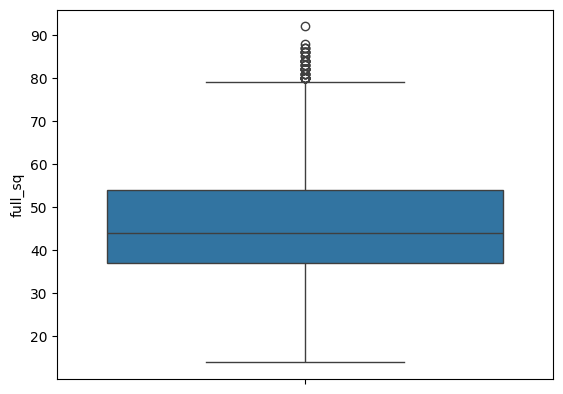

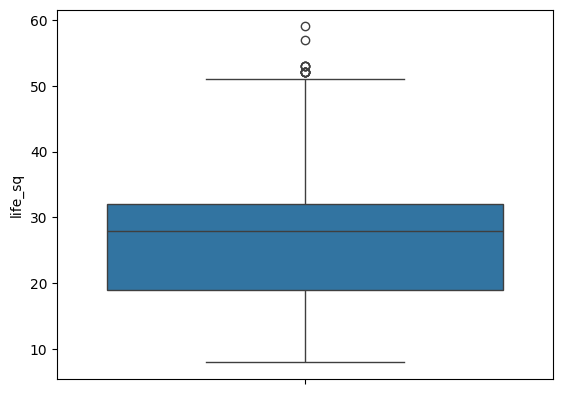

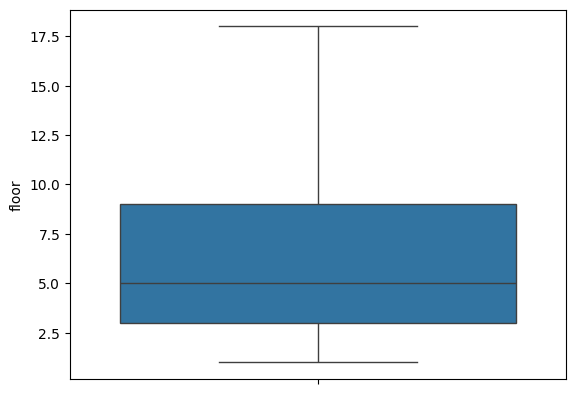

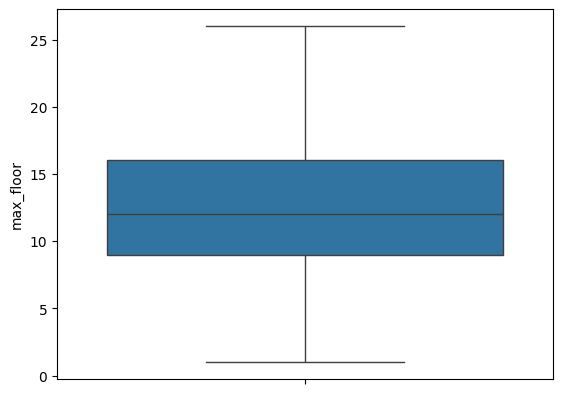

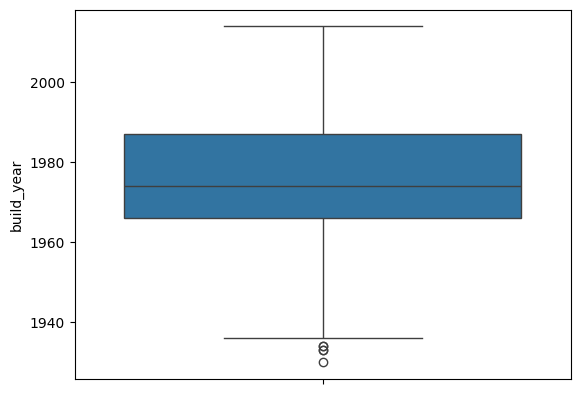

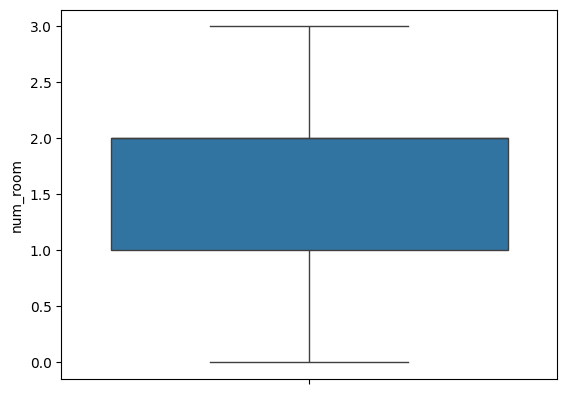

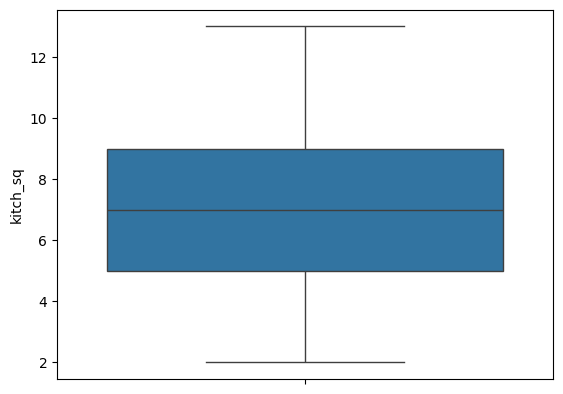

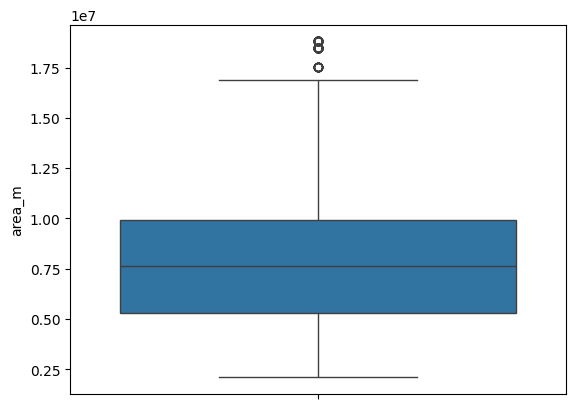

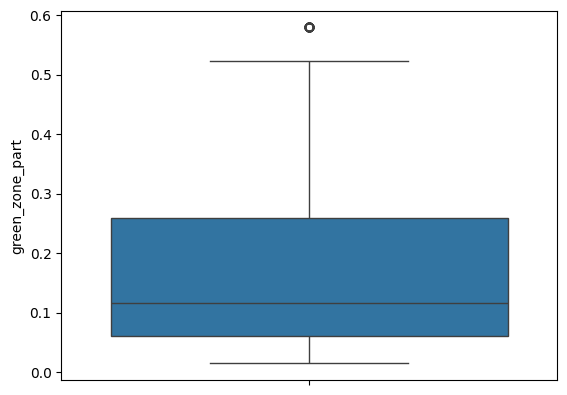

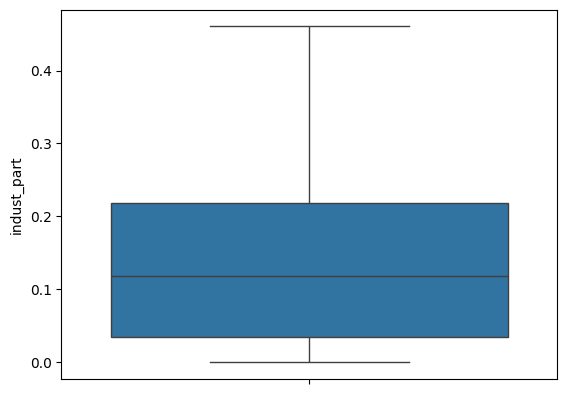

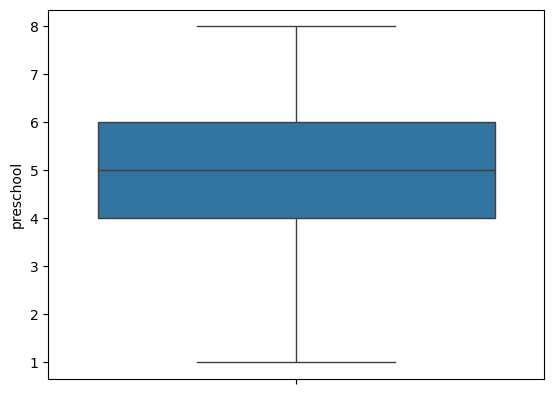

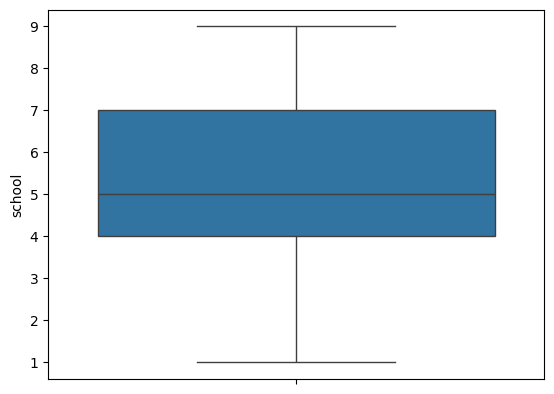

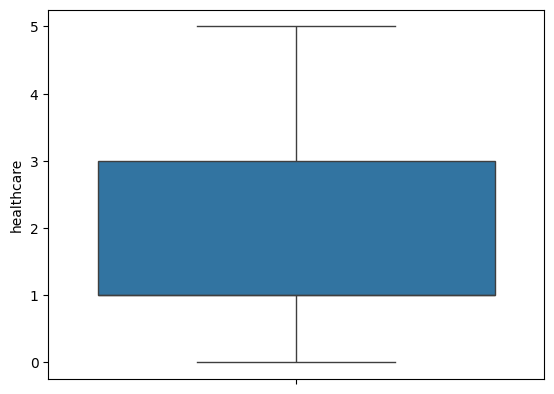

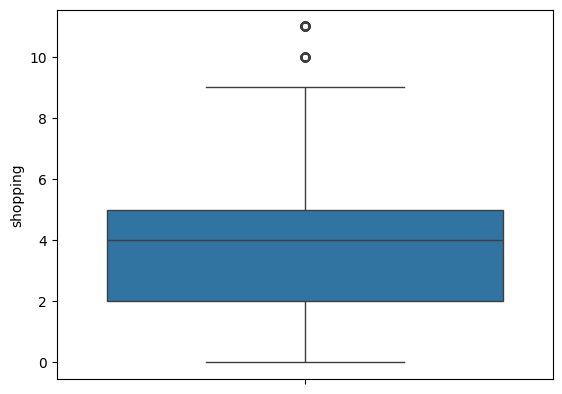

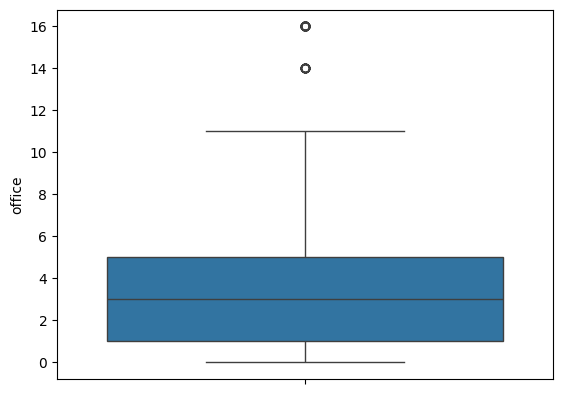

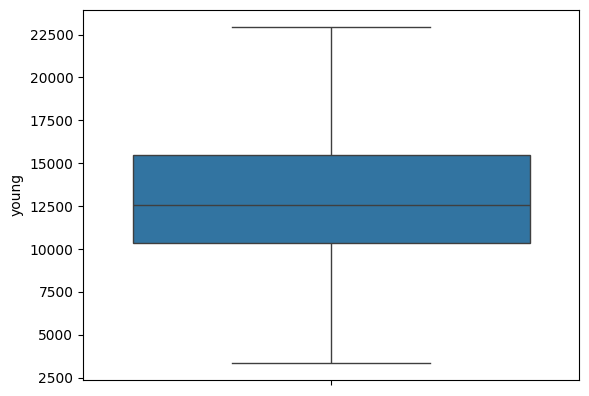

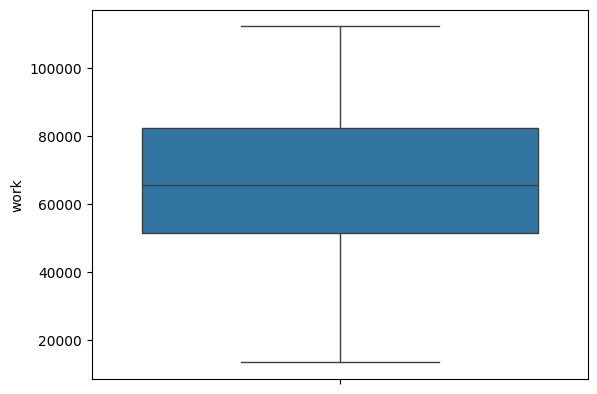

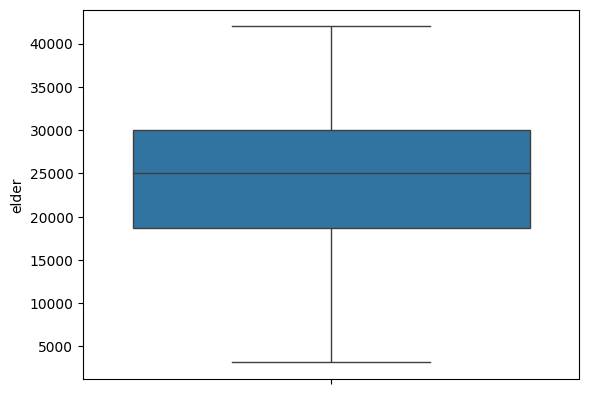

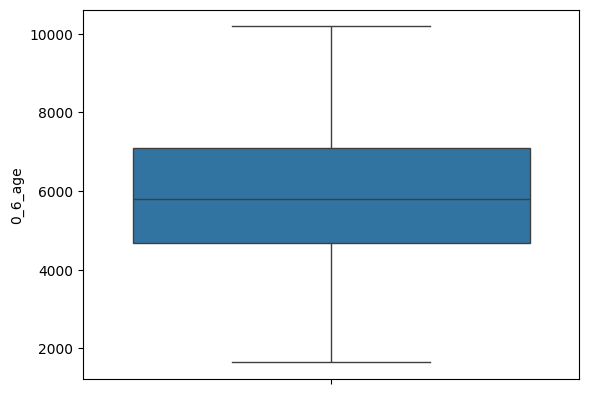

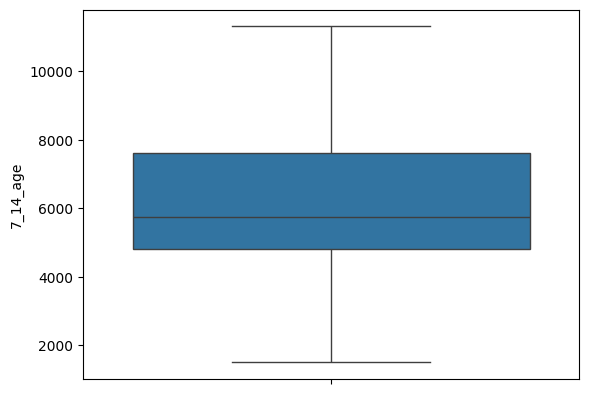

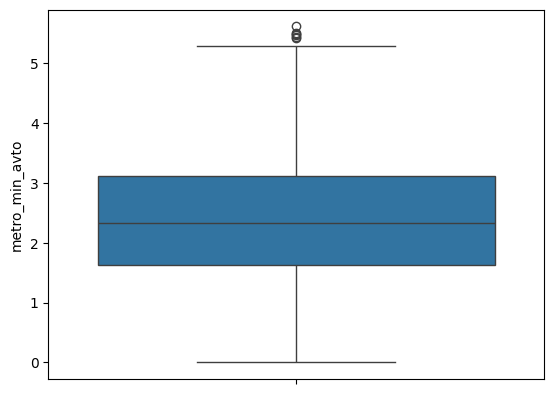

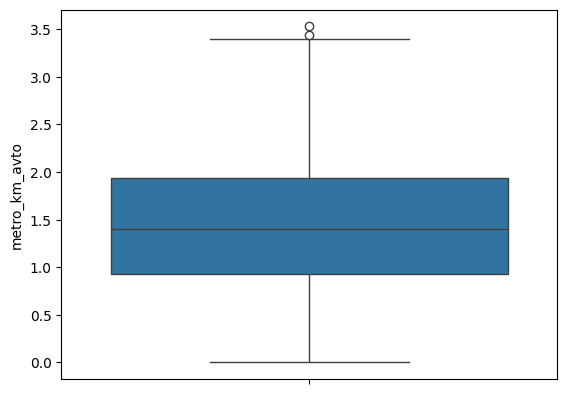

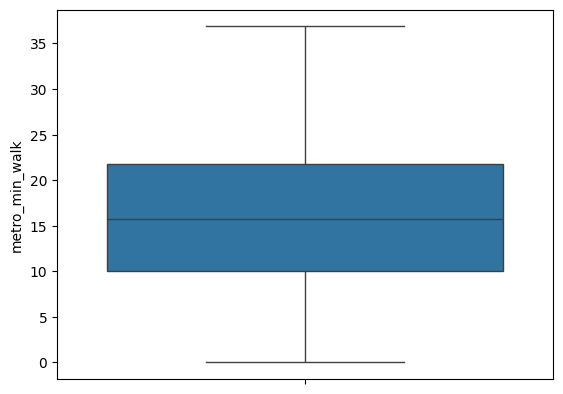

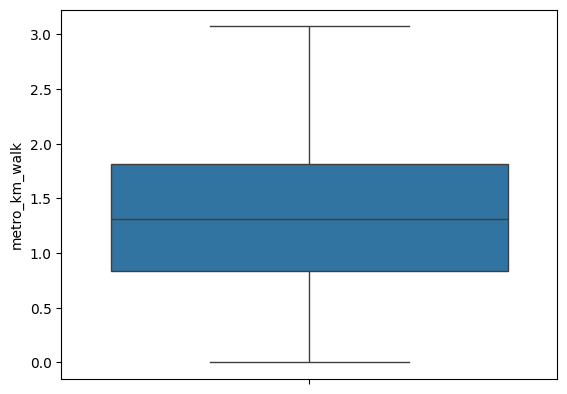

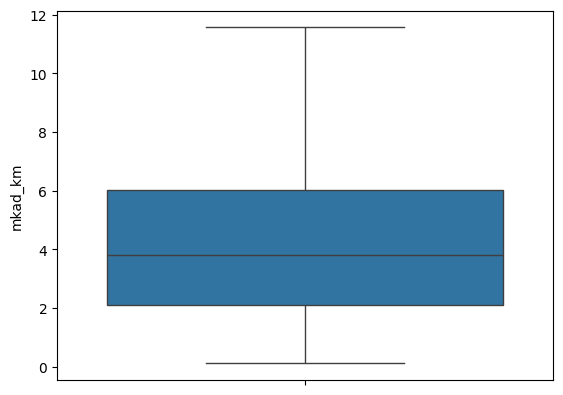

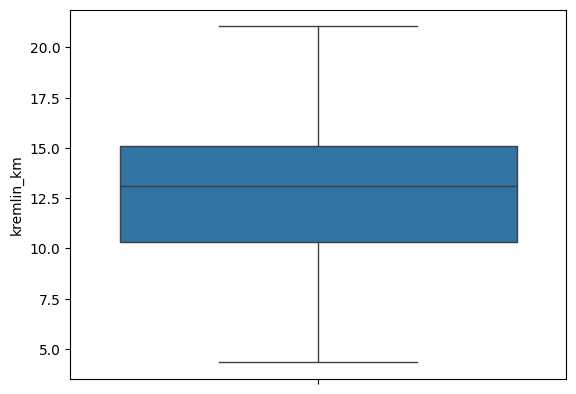

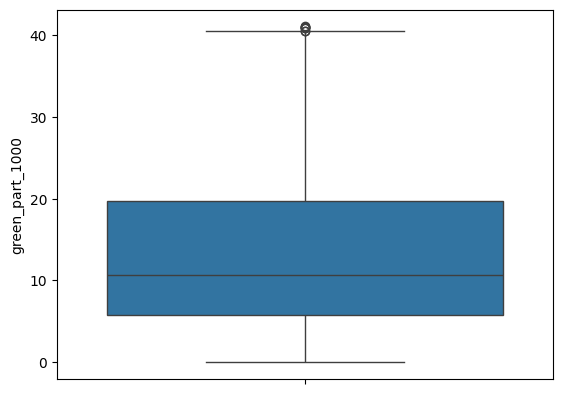

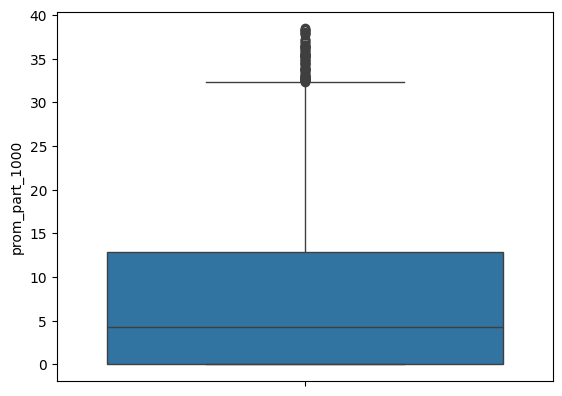

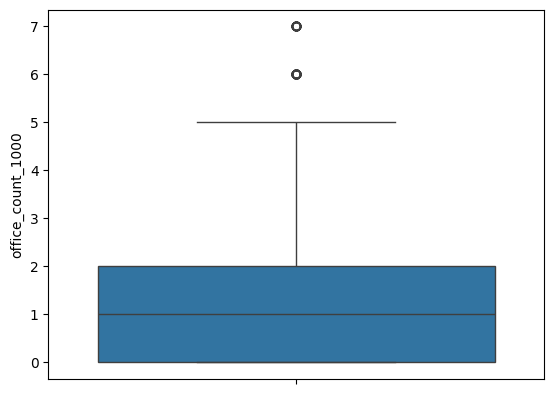

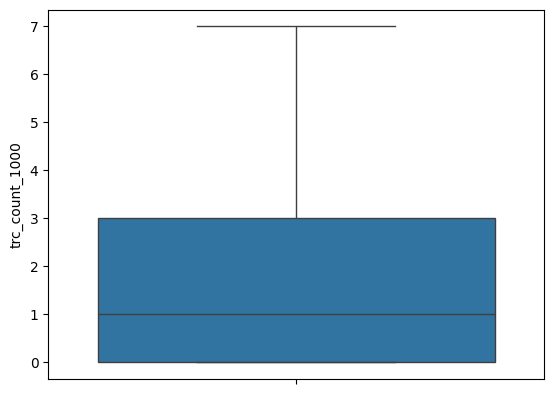

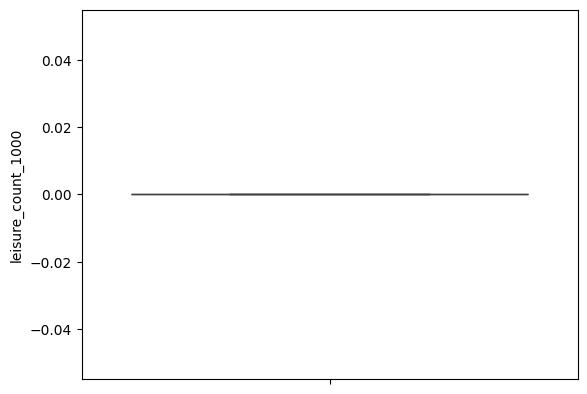

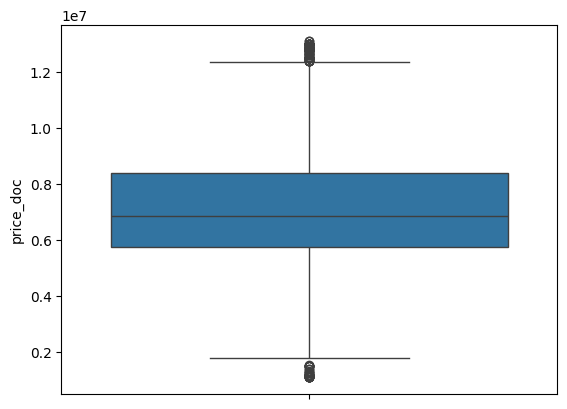

In [ ]:
# посмотрим на данные после удаления выбросов
for _ in df_clean.columns:
    sns.boxplot(df_clean[_])
    plt.show()
    plt.close()

In [13]:
df_clean.duplicated().sum()

np.int64(24)

In [ ]:
# удалим дубликаты
df_clean.drop_duplicates(inplace=True)
df_clean.duplicated().sum()

np.int64(0)

In [15]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 3306 entries, 0 to 8892
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   full_sq             3306 non-null   int64  
 1   life_sq             3306 non-null   float64
 2   floor               3306 non-null   float64
 3   max_floor           3306 non-null   float64
 4   build_year          3306 non-null   float64
 5   num_room            3306 non-null   float64
 6   kitch_sq            3306 non-null   float64
 7   area_m              3306 non-null   float64
 8   green_zone_part     3306 non-null   float64
 9   indust_part         3306 non-null   float64
 10  preschool           3306 non-null   int64  
 11  school              3306 non-null   int64  
 12  healthcare          3306 non-null   int64  
 13  shopping            3306 non-null   int64  
 14  office              3306 non-null   int64  
 15  young               3306 non-null   int64  
 16  work                33

<Axes: >

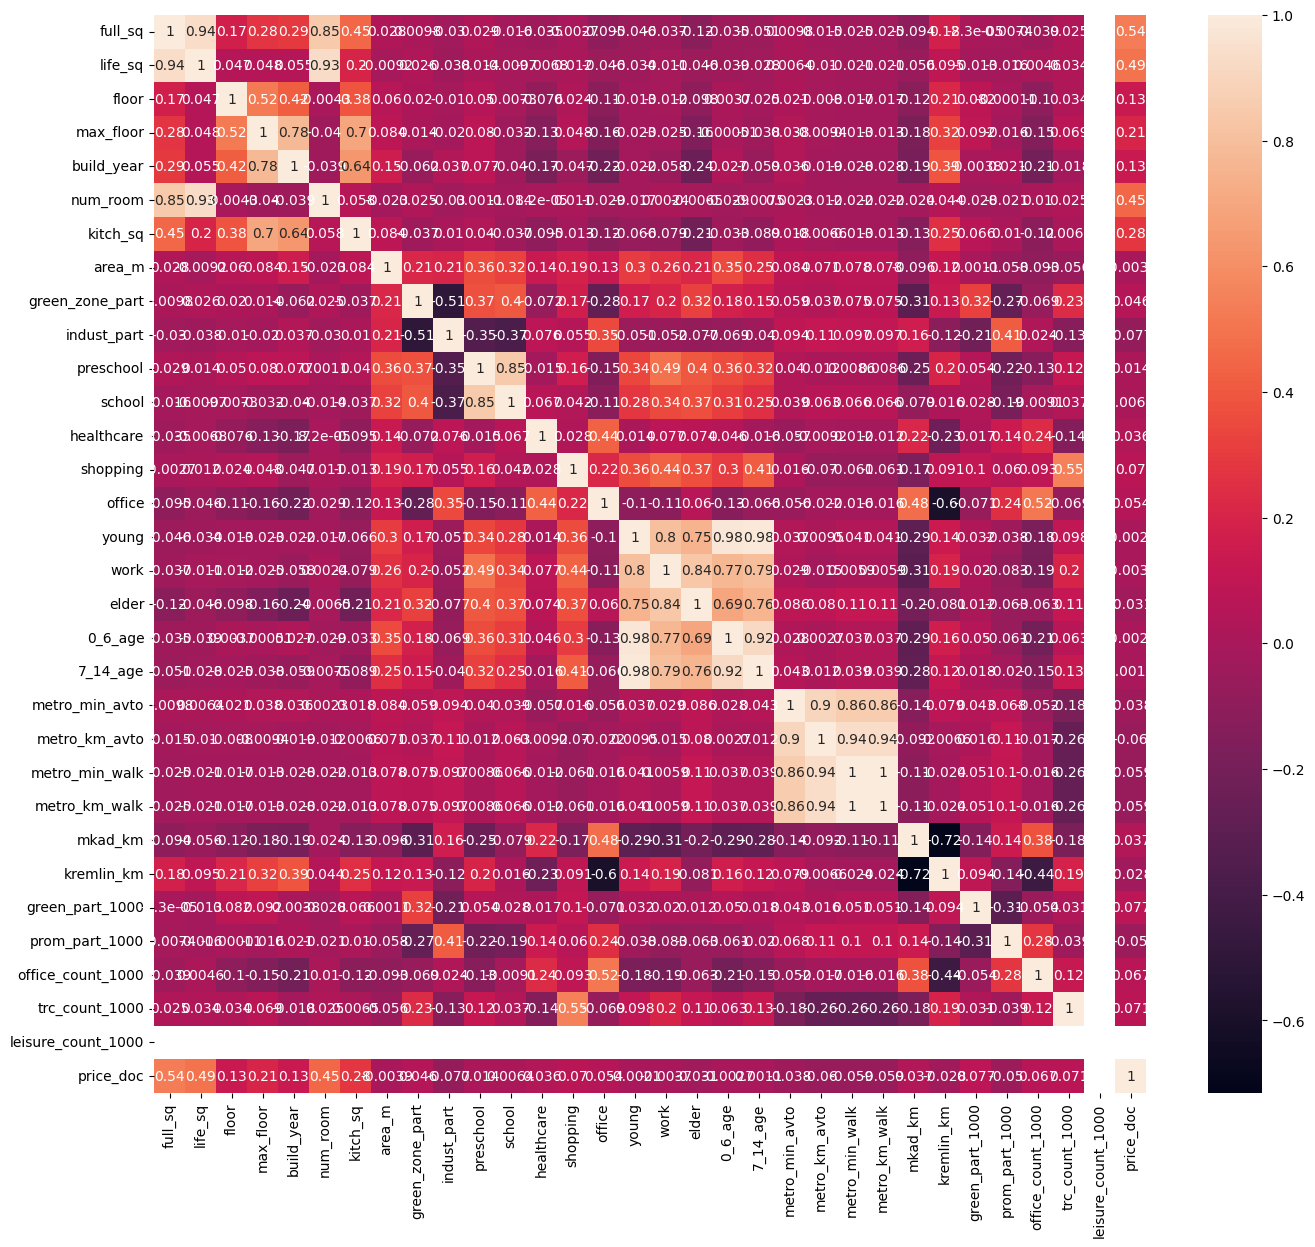

In [33]:
# посмотрим на корреляцию между числовыми переменными
plt.figure(figsize=(16,14))
sns.heatmap(df_clean.corr(), annot=True)

In [53]:
# построим модели линейной регрессии с различными видами регуляризации и без нее, а также сравним их метрики
def full_regression_model(X, Y, test_size=0.2, random_state: str=14):
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=test_size) # разделяем данные на обучающую и валидационную выборку с random_state=13

    np.random.seed(random_state)

    scaler_standart = StandardScaler()
    scaler_normalize = MinMaxScaler()

    x_train_st = scaler_standart.fit_transform(x_train)
    x_train_norm = scaler_normalize.fit_transform(x_train)
    x_test_st = scaler_standart.transform(x_test)
    x_test_norm = scaler_normalize.transform(x_test)

    model_st = LinearRegression()
    model_norm = LinearRegression()
    model_L1 = Ridge()
    model_L2 = Lasso(alpha=100)

    model_st.fit(x_train_st, y_train)
    model_norm.fit(x_train_norm, y_train)

    model_L1.fit(x_train_st, y_train)
    model_L2.fit(x_train_st, y_train)

    y_pred_st = model_st.predict(x_test_st)
    y_pred_norm = model_norm.predict(x_test_norm)
    y_pred_L1 = model_L1.predict(x_test_st)
    y_pred_L2 = model_L2.predict(x_test_st)

    for model in [['парной линейной регрессии с стандартизованными параметрами',model_st, y_pred_st], 
                  ['парной линейной регрессии с нормализованными параметрами',model_norm, y_pred_norm], 
                  ['парной линейной регрессии с Lasso легурязацией и стандартизованными параметрами',model_L2, y_pred_L2],
                  ['парной линейной регрессии с Ridge регуляризацией и стандартизованными параметрами',model_L1, y_pred_L1]]:
        print(60 * '=')
        print('Модель', model[0])
        print(60 * '=')
        print(f' Y = {model[1].intercept_} + X * {model[1].coef_}')
        mse = mean_squared_error(y_test, model[2])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, model[2])
        mape = mean_absolute_percentage_error(y_test, model[2])
        r2 = r2_score(y_test, model[2])
        print("Среднеквадратическая ошибка (MSE):", mse)
        print("Среднеквадратическая ошибка (RMSE):", rmse)
        print("Средняя абсолютная ошибка (MAE):", mae)
        print("Средняя абсолютная ошибка  (MAPE):", mape)
        print("Коэффициент детерминации (R^2):", r2 )
        print("Количесвто переменных:", len(model[1].coef_))
        print("Количество наблюдений обучающей выборки:", len(y_train))
        print(60 * '=')

In [54]:
# запускаем функцию для построения моделей
full_regression_model(df_clean[df_clean.columns[:-1]], df_clean['price_doc'])

Модель парной линейной регрессии с стандартизованными параметрами
 Y = 7054854.683364957 + X * [ 1.30985602e+06 -2.16703376e+05  1.77776033e+04  3.40959767e+05
 -2.02628164e+05  2.29917001e+05  1.35775120e+05 -1.13540224e+04
  4.92152995e+04 -1.59767357e+05 -1.88746830e+05  8.73816315e+04
  7.30047418e+04  1.98959783e+04  1.57360412e+05 -3.41938842e+06
  1.65702247e+05 -1.32308213e+05  1.59187082e+06  1.96532263e+06
  1.00821429e+05 -1.21971583e+05  2.66899723e+12 -2.66899727e+12
 -4.01442842e+04 -3.68751264e+05  8.52997258e+04 -1.10637643e+05
  3.24710384e+04  1.00472143e+05  0.00000000e+00]
Среднеквадратическая ошибка (MSE): 4149860031295.9185
Среднеквадратическая ошибка (RMSE): 2037120.5244893879
Средняя абсолютная ошибка (MAE): 1294660.5022651604
Средняя абсолютная ошибка  (MAPE): 0.35376946151966526
Коэффициент детерминации (R^2): 0.26368257285855445
Количесвто переменных: 31
Количество наблюдений обучающей выборки: 2644
Модель парной линейной регрессии с нормализованными параметр

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.749e+15, tolerance: 1.566e+12
  model = cd_fast.enet_coordinate_descent(


In [55]:
# посмотрим на категориальные переменные и закодируем их с помощью one-hot encoding
df_with_dummies = pd.get_dummies(df, columns=['radiation', 'detention', 'sub_area', 'material']).astype(float)
df_with_dummies

,full_sq,life_sq,floor,max_floor,build_year,num_room,kitch_sq,area_m,green_zone_part,indust_part,...,sub_area_Vyhino-Zhulebino,sub_area_Zamoskvorech'e,sub_area_Zapadnoe Degunino,sub_area_Zjablikovo,sub_area_Zjuzino,material_breezeblock,material_brick,material_mass concrete,material_mass concrete plus brick,material_panel
0,38.0,18.0,1.0,14.0,1971.0,1.0,9.0,7.126815e+06,0.125882,0.458174,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,41.0,17.0,14.0,16.0,1978.0,1.0,10.0,2.641243e+06,0.015900,0.051942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,41.0,20.0,11.0,14.0,1989.0,1.0,8.0,1.084231e+07,0.062172,0.161532,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,38.0,19.0,6.0,17.0,1986.0,1.0,8.0,7.587523e+06,0.398794,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,58.0,37.0,3.0,9.0,1968.0,3.0,6.0,4.395333e+06,0.063755,0.038693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8889,51.0,32.0,3.0,12.0,1974.0,2.0,9.0,1.844581e+07,0.030697,0.428826,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8890,76.0,45.0,6.0,16.0,2001.0,3.0,10.0,1.175477e+07,0.188713,0.090799,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8891,78.0,43.0,15.0,17.0,2002.0,3.0,13.0,8.889467e+06,0.579645,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8892,54.0,28.0,7.0,16.0,1975.0,2.0,12.0,1.020722e+07,0.512707,0.000170,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [56]:
# посмотрим на данные после удаления выбросов для всех числовых переменных, а не по одной
df_clean_all = df_numeric.copy()

for col in df_clean_all.columns:
    

    Q1 = df_clean_all[col].quantile(0.25)
    
    # Q3 — третий квартиль (75%)
    Q3 = df_clean_all[col].quantile(0.75)
    
    # Межквартильный размах
    IQR = Q3 - Q1
    
    # Границы для выбросов
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Фильтрация: оставляем только строки, где значения в границах
    df_clean_all = df_clean_all[(df_clean_all[col] >= lower_bound) & (df_clean_all[col] <= upper_bound)]
df_clean_all

,full_sq,life_sq,floor,max_floor,build_year,num_room,kitch_sq,area_m,green_zone_part,indust_part,...,metro_min_walk,metro_km_walk,mkad_km,kremlin_km,green_part_1000,prom_part_1000,office_count_1000,trc_count_1000,leisure_count_1000,price_doc
0,38,18.0,1.0,14.0,1971.0,1.0,9.0,7.126815e+06,0.125882,0.458174,...,27.084184,2.257015,2.442781,14.856442,17.16,10.33,2,4,0,5150000
3,38,19.0,6.0,17.0,1986.0,1.0,8.0,7.587523e+06,0.398794,0.000000,...,14.085660,1.173805,2.885041,14.921056,24.97,0.00,0,5,0,5650000
7,37,19.0,12.0,14.0,1975.0,1.0,9.0,1.051837e+07,0.334905,0.012339,...,28.826423,2.402202,0.723894,13.012073,4.29,0.49,0,2,0,5800000
15,34,16.0,10.0,22.0,1987.0,1.0,10.0,4.602090e+06,0.114157,0.000000,...,2.492782,0.207732,2.008591,16.094809,6.22,0.00,0,4,0,5600000
17,32,18.0,2.0,9.0,1975.0,1.0,5.0,6.879020e+06,0.061477,0.282798,...,22.418835,1.868236,3.290269,15.350024,39.26,0.00,0,0,0,4900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8878,35,19.0,12.0,12.0,1966.0,1.0,9.0,8.841267e+06,0.127512,0.307467,...,36.162889,3.013574,3.758840,13.157628,2.63,24.21,0,0,0,5950000
8879,36,21.0,9.0,9.0,1970.0,1.0,6.0,1.428699e+07,0.389354,0.194489,...,34.137039,2.844753,0.822871,14.671947,30.88,3.60,0,1,0,2000000
8881,39,21.0,1.0,14.0,1992.0,1.0,9.0,3.707575e+06,0.030566,0.041365,...,16.431388,1.369282,0.390552,14.150189,2.67,4.81,0,6,0,5830000
8889,51,32.0,3.0,12.0,1974.0,2.0,9.0,1.844581e+07,0.030697,0.428826,...,17.320003,1.443334,6.756490,9.929204,13.61,4.32,1,0,0,8300000


In [57]:
# запускаем функцию для построения моделей на данных, очищенных от выбросов по всем числовым переменным 
full_regression_model(df_clean_all[df_clean_all.columns[:-1]], df_clean_all['price_doc'])

Модель парной линейной регрессии с стандартизованными параметрами
 Y = 7052752.232852289 + X * [ 1.29247959e+06 -1.90265865e+05  6.44930106e+04  3.39374021e+05
 -2.44796723e+05  1.72165893e+05  1.16078203e+05 -2.11384729e+04
  4.71232722e+04 -1.33954687e+05 -1.84888080e+05  9.09390094e+04
  7.28541590e+04  3.13456994e+04  1.42128504e+05 -4.11145358e+06
  2.14214242e+05 -2.25896568e+05  1.96455418e+06  2.36143817e+06
  8.71961449e+04 -9.14089306e+04  4.19682213e+13 -4.19682213e+13
  7.16349982e+03 -3.54106068e+05  1.42758011e+05 -1.18166940e+05
  3.39766398e+04  1.02632397e+05  0.00000000e+00]
Среднеквадратическая ошибка (MSE): 3746037478701.6406
Среднеквадратическая ошибка (RMSE): 1935468.2840856991
Средняя абсолютная ошибка (MAE): 1252681.7347452515
Средняя абсолютная ошибка  (MAPE): 0.3438839635558348
Коэффициент детерминации (R^2): 0.3532061153698717
Количесвто переменных: 31
Количество наблюдений обучающей выборки: 2664
Модель парной линейной регрессии с нормализованными параметрам

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.121e+15, tolerance: 1.574e+12
  model = cd_fast.enet_coordinate_descent(


<Axes: >

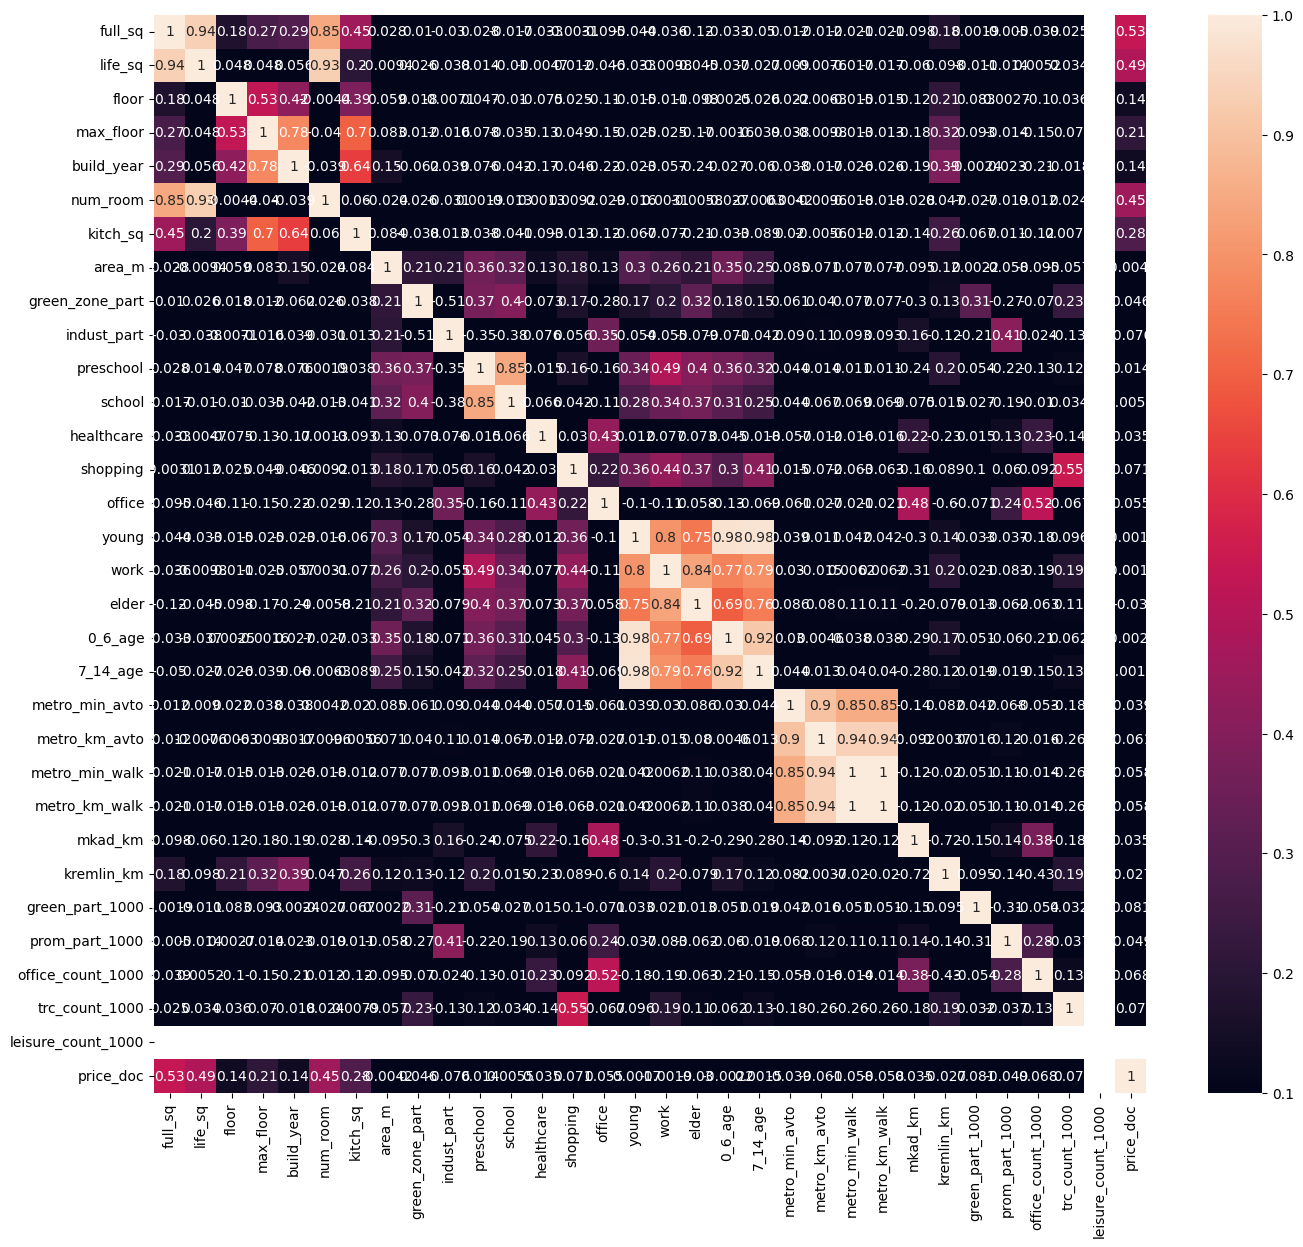

In [58]:
# посмотрим на корреляцию между числовыми переменными
plt.figure(figsize=(16,14))
sns.heatmap(df_clean_all.corr(), annot=True, vmin=0.1)

In [64]:
threshold = 0.1 # устанавливаем порог
correlations = df_clean_all.corr()['price_doc'].abs().sort_values(ascending=False)

# Отбираем признаки с корреляцией выше порога (исключая саму целевую)
selected_features = correlations[correlations > threshold].index.tolist()
if 'price_doc' in selected_features:
    selected_features.remove('price_doc')

full_regression_model(df_clean_all[selected_features], df_clean_all['price_doc']) # строим модель по коррелированным переменным

Модель парной линейной регрессии с стандартизованными параметрами
 Y = 7052752.251126123 + X * [1305078.63017229 -205392.28986216  154430.32711882  114317.68268821
  423295.83927185   54366.75109978 -485459.63164647]
Среднеквадратическая ошибка (MSE): 3889412609430.7725
Среднеквадратическая ошибка (RMSE): 1972159.3772894656
Средняя абсолютная ошибка (MAE): 1295242.5103858807
Средняя абсолютная ошибка  (MAPE): 0.3468000984316019
Коэффициент детерминации (R^2): 0.32845084842689676
Количесвто переменных: 7
Количество наблюдений обучающей выборки: 2664
Модель парной линейной регрессии с нормализованными параметрами
 Y = 4031046.069336404 + X * [ 7819378.29175735 -1146785.78877318   627657.97334153   654851.52943283
  2209137.77521118   222841.3302285  -2650277.1581377 ]
Среднеквадратическая ошибка (MSE): 3889412609430.7725
Среднеквадратическая ошибка (RMSE): 1972159.3772894656
Средняя абсолютная ошибка (MAE): 1295242.5103858805
Средняя абсолютная ошибка  (MAPE): 0.346800098431602
Коэффицие

## Итоги
1. В этой работе использовались только пройднные нами, в частности мной темы, возможно, при работе с бустингами и решающими лесами получаться более точные результаты.
2. Также стоит отметить само задание: отыскание модели с наименьшей средней суммы квадратов отклонений (MSE), то есть при изменение целевой переменной, например приведения к другой функциональной форме или стандартизации, MSE может сильно отличаться из-за изменения разрядности отклонений, например логарифм целевой переменной.
3. Возможно, было бы удобнее использовать скоректированный коэффициент детерминации для определения качества любой модели. У меня R_2 получился лучшим 0.35 при использовании всех объясняющих переменных, категориальных переведенных в фиктивные, устранение выбросов и дубликатов.